# Multivariate Normal Distribution

`MultivariateNormal(mean, cov)` generalizes the normal distribution to several dimensions at once. Each draw is a *vector* of correlated normal values, described by a mean vector and a covariance matrix.

In [1]:
from symbulate import *

## Draw a value

Each draw is a vector, one entry per dimension.

In [2]:
MultivariateNormal(mean=[0, 0], cov=[[1, 0.8], [0.8, 1]]).draw()

(0.12465285775403734, 1.2087849904583252)

## Simulate

Every simulated value is a 2-dimensional vector.

In [3]:
MultivariateNormal(mean=[0, 0], cov=[[1, 0.8], [0.8, 1]]).sim(1000)

0,"(0.37700449574344674, -0.08679278775209062)"
1,"(0.1557070839587216, 0.5005420058979305)"
2,"(0.5048494745803219, 0.5392156481265338)"
3,"(1.1766743855617132, 0.7416316446830751)"
4,"(-1.099345502623339, -1.2042962552387504)"
5,"(0.08751302966965113, 0.6941541365241286)"
6,"(-0.7508697812227388, -0.8949928539331042)"
7,"(0.8546484973104171, 1.3464303332749226)"
8,"(-0.998820788282017, -1.4286312451039889)"
...,...
999,"(0.049154538268326615, 0.16875405505704694)"


## Mean, variance, and standard deviation

For a vector-valued distribution these each return one value per component.

In [4]:
X = MultivariateNormal(mean=[1, 2, 3], cov=[[4, 1, 0.5], [1, 2, -0.3], [0.5, -0.3, 1]])
X.mean(), X.var(), X.sd()

((1, 2, 3), (4.0, 2.0, 1.0), (2.0, 1.4142135623730951, 1.0))

## Covariance matrix

`cov()` returns the full covariance matrix.

In [5]:
X.cov()

array([[ 4. ,  1. ,  0.5],
       [ 1. ,  2. , -0.3],
       [ 0.5, -0.3,  1. ]])

## Correlation matrix

`corr()` rescales the covariance matrix into correlations between -1 and 1.

In [6]:
X.corr()

array([[ 1.        ,  0.35355339,  0.25      ],
       [ 0.35355339,  1.        , -0.21213203],
       [ 0.25      , -0.21213203,  1.        ]])

## Evaluate the pdf at a point

In [7]:
MultivariateNormal(mean=[0, 0], cov=[[1, 0.8], [0.8, 1]]).pdf([0, 0])

np.float64(0.26525823848649227)

## Plot the joint distribution



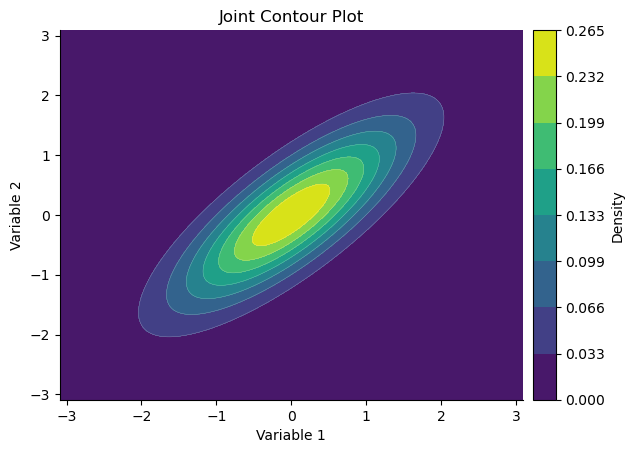

In [8]:
MultivariateNormal(mean=[0, 0], cov=[[1, 0.8], [0.8, 1]]).plot()

A negative covariance tilts the shape the other way. Large values of one
variable go with small values of the other.

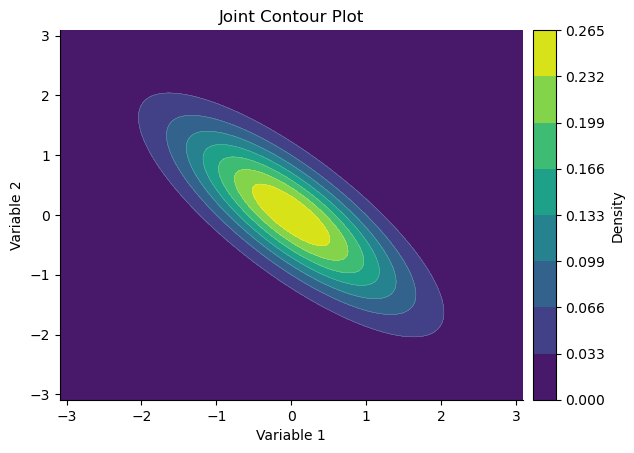

In [9]:
MultivariateNormal(mean=[0, 0], cov=[[1, -0.8], [-0.8, 1]]).plot()

With zero covariance the two variables are independent, and the shape has no
tilt at all.

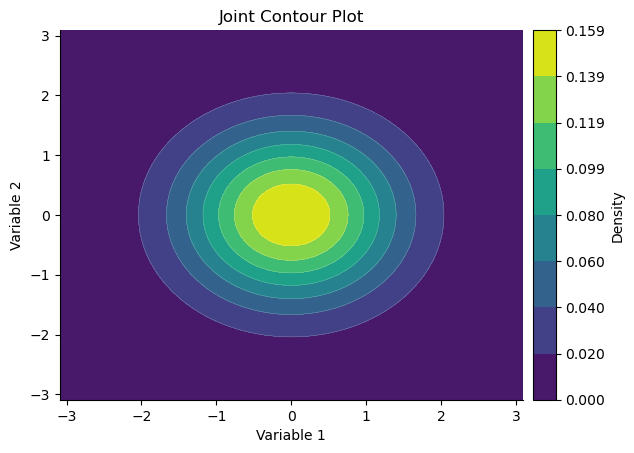

In [10]:
MultivariateNormal(mean=[0, 0], cov=[[1, 0], [0, 1]]).plot()

### Contour lines instead of a smooth surface


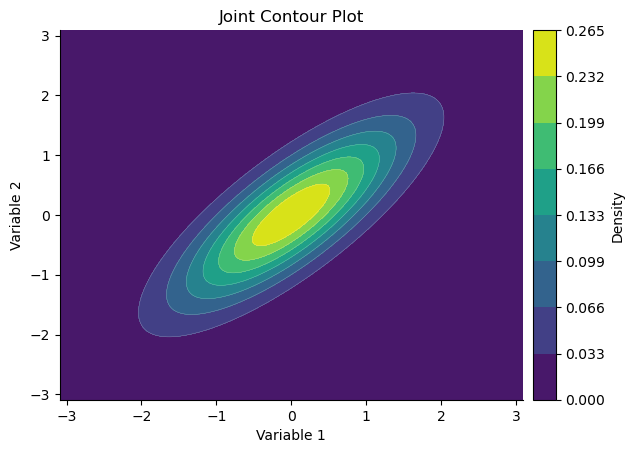

In [11]:
MultivariateNormal(mean=[0, 0], cov=[[1, 0.8], [0.8, 1]]).plot(contour=True)

## More than two variables: pick a pair with `dims`

With three or more variables there is no single joint plot to show, so `plot()`
asks which two you want. `X.plot()` with no arguments raises an error saying so.

Variables are numbered from 0, so `variables=[0, 1]` means the 1st and 2nd. These
two have the strongest correlation of the three, about 0.35, so their tilt is
the clearest.

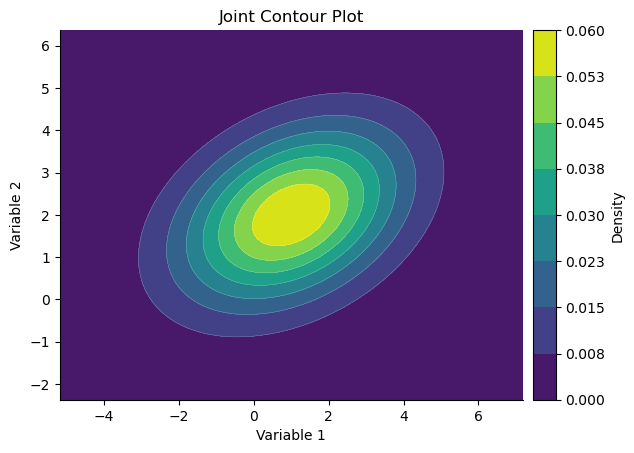

In [12]:
X.plot(variables=(0, 1))

Variables 1 and 2 have a negative correlation, about -0.21, so this pair leans
the other way. The lean is slight because the correlation is weak.

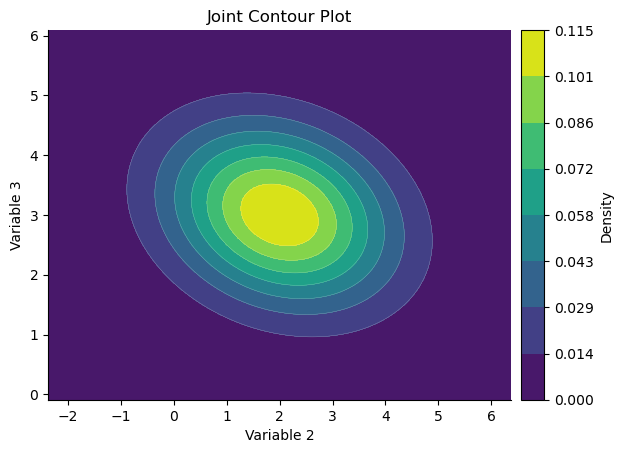

In [13]:
X.plot(variables=(1, 2))

## Every pair at once (the default)

With three or more variables, `.plot()` draws every pair in one grid. The diagonal shows each variable on
its own, which is an ordinary `Normal`. Each panel below the diagonal shows one
pair.

Only the lower triangle is drawn. The upper half would repeat the same pairs
with the axes swapped.

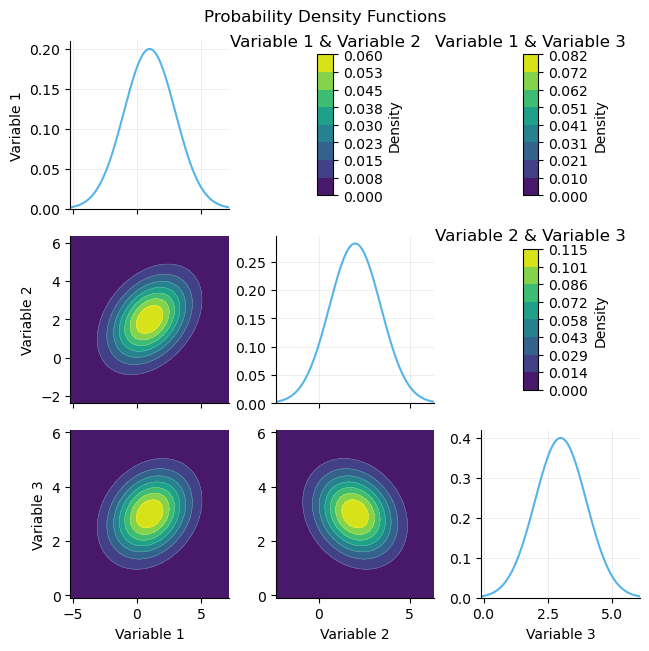

In [14]:
X.plot()